## Növények növekedése – gyakorló adathalmaz

Egy biológiai vizsgálat során diákcsoport a növények növekedését követi nyomon.  
Az adathalmaz két független változót és egy célváltozót tartalmaz:

- **ido** – a napok száma, amióta a növények növekedésnek indultak  
- **talajnedvesseg** – a talaj nedvessége milliméterben  
- **magassag** – a növények magassága centiméterben  

A megfigyelések szerint a növények növekedése kezdetben gyors, majd lassul, ezért az **ido** változó másodfokú kapcsolatot mutat a magassággal.  
A talaj nedvessége lineárisan befolyásolja a növények magasságát, kisebb mértékben, mint az idő.

## 1. feladat – Adathalmaz betöltése

Olvassuk be a gyakorló adathalmazt a `novenyek.csv` fájlból

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
pd.set_option('display.max_columns', None)

df = pd.read_csv('novenyek.csv')
df.head(10)

,ido,talajnedvesseg,magassag
0,0.248357,31.273938,8.825543
1,0.543113,84.175758,27.394985
2,1.548334,25.964051,11.319773
3,2.598250,98.950955,37.494166
4,2.331903,81.779582,28.337351
5,2.944156,35.897255,16.868970
6,4.463076,20.441769,16.266371
7,4.669432,85.236914,34.163267
8,4.663222,76.548588,35.057825
9,5.781484,78.320573,38.923807


## 2. feladat – Lineáris regresszió az idő változóval

Készítsünk egy **lineáris regressziós modellt** az `ido` és a `magassag` változó között, majd vizualizáljuk az adatokat és az illesztett egyenest.  

<Axes: xlabel='ido', ylabel='magassag'>

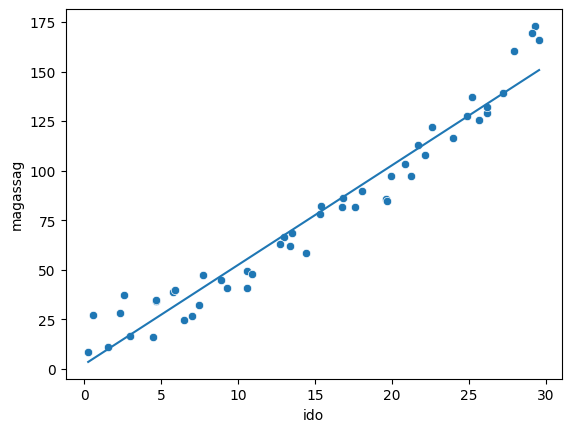

In [3]:
from sklearn.linear_model import LinearRegression

X = df[['ido']].to_numpy()
X[:10]

y = df['magassag'].to_numpy()
y[:10]

reg = LinearRegression()
reg.fit(X,y)

theta0 = reg.intercept_
theta1 = reg.coef_[0]
h = theta0 + theta1 * df['ido']
sns.scatterplot(x=df['ido'],y=df['magassag'])
sns.lineplot(x=df['ido'],y=h)

## 3. feladat – Modell értékelése R² segítségével

Számoljuk ki a lineáris regressziós modell **R² értékét** az `ido` és `magassag` változó között, majd jelenítsük meg a képernyőn.  

In [4]:
r2 = reg.score(X, y)
print(r2)

0.9490025038480141


## 4. feladat – Másodfokú polinom illesztése az idő változóra

Illesszünk egy **másodfokú polinomot** az `ido` és a `magassag` változó közé.  
Vizualizáljuk az adatokat és az illesztett polinom görbét, hogy lássuk a növekedés kezdeti gyorsaságát és a későbbi lassulást.

<Axes: xlabel='ido', ylabel='magassag'>

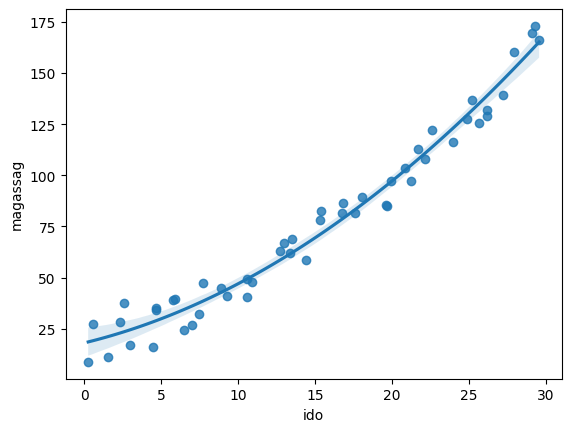

In [5]:
sns.regplot(x='ido', y='magassag', data=df, order=2)